In [3]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

%load_ext autoreload 

%autoreload 2
%matplotlib inline



In [ ]:

from systematic_plots import load_ocp_paths, load_doeke_paths, load_defaults, load_homepath, calculate_objects, load_photolyase_paths
from systematic_plots import cut_resolution, calculate_scaled_maps
import reciprocalspaceship as rs
def get_ds_from_data_real(conds):
    evaluation_path = load_homepath() + "../evaluation/"
    if "ocp":
        info_container=load_ocp_paths()[0]
    elif "doeke":
        info_container=load_doeke_paths()[0]
    elif "photolyase":
        info_containers=load_photolyase_paths()
        for info_container in info_containers:
            if info_container['fshort'] == "PL30ns" and info_container['datatype'] == "photolyase":
                break

    filename_dict, defaults_to_overwrite, function_selection, blob_selection_func = load_defaults()

    info_container = defaults_to_overwrite | info_container 

    dataloc_dark = info_container["dataloc_dark"]
    dataloc_light = info_container["dataloc_light"]

    hs_limit = info_container["hs_limit"]
    map_sampling = info_container["map_sampling"]

    ds_light = rs.read_mtz(dataloc_light)
    ds_dark = rs.read_mtz(dataloc_dark)

# ds_dark = cut_resolution(ds_dark, high_resolution_limit=hs_limit)
# ds_light = cut_resolution(ds_light, high_resolution_limit=hs_limit)
conds =  {
"dark_phases": True,
"offset" : True,
"diffmap_func": "kweighted",
}
from systematic_cistrans import shift_offset
from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
def get_diffmap(ds_dark, ds_light, info_container, conds):
    info_container = info_container.copy() | conds
    map_dark, map_light = calculate_scaled_maps(ds_dark, ds_light, info_container)
    if conds["offset"]:
        map_dark = shift_offset(map_dark.copy() )
        map_light = shift_offset(map_light.copy() )
    if conds["diffmap_func"] == "vanilla":
        diffmap =  compute_difference_map(map_light, map_dark)
    elif conds["diffmap_func"] == "kweighted":
        diffmap = max_negentropy_kweighted_difference_map(map_light, map_dark)
    else:
        raise ValueError("Unknown diffmap function")
    return diffmap


dark_phases = [False, True]
offsets = [False, True]
diffmap_funcs = ["vanilla", "kweighted"]
# carthe 
import itertools
carthesian_product = itertools.product(dark_phases, offsets, diffmap_funcs)
diffmap_list = []
for dark_phase, offset, diffmap_func in carthesian_product:
    conds =  {
    "dark_phases": dark_phase,
    "offset" : offset,
    "diffmap_func": diffmap_func,
    }
    
    diffmap = get_diffmap(ds_dark, ds_light, info_container, conds)
    diffmap_list.append(
        (diffmap, conds))

2025-09-09 15:31:43,833: logger: INFO: Loading Doeke paths (systematic_plots.py:1376)


KeyboardInterrupt: 

In [1]:
from compare_diffmaps import get_diffmaps

IndentationError: unexpected indent (compare_diffmaps.py, line 63)

In [ ]:
constants = {"high_resolution_limit": 2}
f_noise, phi_noise = 0., 0.
occupancy = 0.3
from generate_objects import generate_obj_cistrans_v3
    map_dark, map_light = generate_obj_cistrans_v3(
        occupancy, f_noise=f_noise, phi_noise=phi_noise, hs_limit=constants["high_resolution_limit"]
    )
    if offset:
        map_dark = shift_offset(map_dark.copy() )
        map_light = shift_offset(map_light.copy() )
    if not dark_phases:
        map_light["PHI"] = map_dark["PHI"]

    diffmap = compute_difference_map(map_light, map_dark, check_isomorphous=False)


In [16]:
info_container["dark_phases"] = True
map_dark, map_light_dark_phases = calculate_scaled_maps(ds_dark, ds_light, info_container)
diffmap_vanilla_dark_phases = compute_difference_map(map_light_dark_phases, map_dark)
diffmap_kweighted_dark_phases, kweighted_meta_dark_phases = max_negentropy_kweighted_difference_map(map_light_dark_phases, map_dark, )


In [16]:
import matplotlib.pyplot as plt
import numpy as np
bins = np.linspace(-0.12, .12, 200)
diffmap_vanilla_np = diffmap_vanilla.to_3d_numpy_map(map_sampling=3)
diffmap_vanilla_dark_phases_np = diffmap_vanilla_dark_phases.to_3d_numpy_map(map_sampling=3)
diffmap_kweighted_np = diffmap_kweighted.to_3d_numpy_map(map_sampling=3)
diffmap_kweighted_dark_phases_np = diffmap_kweighted_dark_phases.to_3d_numpy_map(map_sampling=3)    
plt.figure()
plt.hist(diffmap_vanilla_np.flatten(), bins=bins, alpha=0.5, label="vanilla")
plt.hist(diffmap_vanilla_dark_phases_np.flatten(), bins=bins, alpha=0.5, label="vanilla dark phases")
plt.hist(diffmap_kweighted_np.flatten(), bins=bins, alpha=0.5, label="kweighted")
plt.hist(diffmap_kweighted_dark_phases_np.flatten(), bins=bins, alpha=0.5, label="kweighted dark phases")
plt.yscale('log')
plt.legend()

NameError: name 'diffmap_vanilla_dark_phases' is not defined

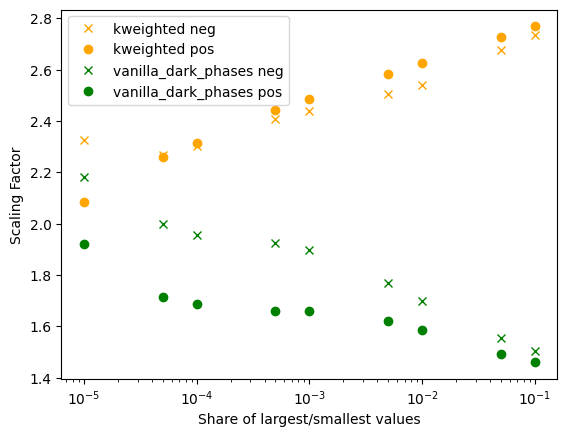

In [28]:
def get_scaling_factors(diffmaps, rescale_key, diffmap_id, shares, map_sampling=3):
    ref_map = diffmaps[rescale_key].to_3d_numpy_map(map_sampling=map_sampling)
    scale_map = diffmaps[diffmap_id].to_3d_numpy_map(map_sampling=map_sampling)
    neg_scales = []
    pos_scales = []
    for share in shares:
        k = int(share * ref_map.size)
        # Get k largest values
        largest_indices = np.argpartition(ref_map.flatten(), -k)[-k:]
        largest_values_ref = ref_map.flatten()[largest_indices]
        largest_indices = np.argpartition(scale_map.flatten(), -k)[-k:]
        largest_values_scale = scale_map.flatten()[largest_indices]

        # Get k smallest values
        smallest_indices = np.argpartition(ref_map.flatten(), k)[:k]
        smallest_values_ref = ref_map.flatten()[smallest_indices]
        smallest_indices = np.argpartition(scale_map.flatten(), k)[:k]
        smallest_values_scale = scale_map.flatten()[smallest_indices]
        # Compute scaling factors using percentiles
        pos_scale = np.mean(largest_values_ref) / np.mean(largest_values_scale)
        neg_scale = np.mean(smallest_values_ref) / np.mean(smallest_values_scale)
        neg_scales.append(neg_scale)
        pos_scales.append(pos_scale)
    return neg_scales, pos_scales

diffmaps = {
    "vanilla": diffmap_vanilla,
    "kweighted": diffmap_kweighted,
    "vanilla_dark_phases": diffmap_vanilla_dark_phases,
    # "kweighted_dark_phases": diffmap_kweighted_dark_phases,
}
scale_factors = {}
colors = ["orange", "green", "red", "blue", ]
plt.figure()
shares = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
rescale_key = "vanilla"
# rescale_key = "vanilla_dark_phases"
for key, diffmap in diffmaps.items():


    if key == rescale_key:
        continue
    neg_scales, pos_scales = get_scaling_factors(
        diffmaps, rescale_key, key, shares, map_sampling=map_sampling
    )
    color = colors.pop(0)
    plt.plot(shares, neg_scales, label=key + " neg", linestyle="", marker="x", color=color)
    plt.plot(shares, pos_scales, label=key + " pos", linestyle="", marker = "o", color=color)
    scale_factors[ key + "_neg"] = neg_scales
    scale_factors[ key + "_pos"] = pos_scales
plt.legend()
plt.xlabel("Share of largest/smallest values")
plt.ylabel("Scaling Factor")
plt.xscale("log")
plt.show()


Minimums: -0.1700093 -0.17952259
Mean: 0.009513295 -8.6588445e-12
Max: 0.12296109 0.1134478


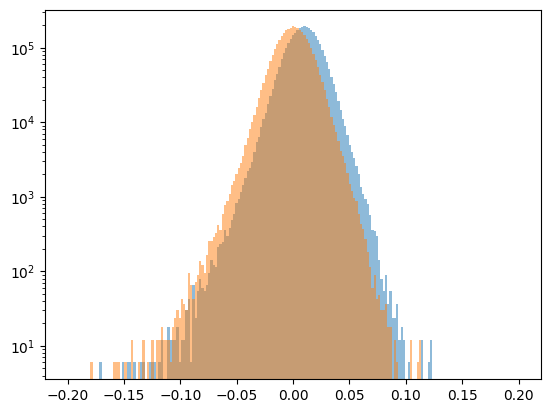

In [6]:
from meteor.diffmaps import compute_difference_map
diffmap_vanilla = compute_difference_map(map_light, map_dark)
diffmap_vanilla_shift = compute_difference_map(map_light_shift, map_dark_shift)
diffmap_vanilla_np = diffmap_vanilla.to_3d_numpy_map(map_sampling=3)
diffmap_vanilla_shift_np = diffmap_vanilla_shift.to_3d_numpy_map(map_sampling=3)
import matplotlib.pyplot as plt
import numpy as np
bins = 0.2 * np.linspace(-1, 1, 200)
plt.figure()
plt.hist(diffmap_vanilla_shift_np.flatten(), bins=bins, alpha=0.5, label="vanilla shift")
plt.hist(diffmap_vanilla_np.flatten(), bins=bins, alpha=0.5, label="vanilla shift")
print("Minimums:", diffmap_vanilla_shift_np.min(), diffmap_vanilla_np.min())
print("Mean:", diffmap_vanilla_shift_np.mean(), diffmap_vanilla_np.mean())
print("Max:", diffmap_vanilla_shift_np.max(), diffmap_vanilla_np.max())
plt.yscale('log')
